# USE CASE 2: Disaster Preparedness and Resource Pre-positioning

## For: National Disaster Management Authorities, Emergency Response Agencies

### Key Questions This Analysis Answers:
1. **Which hazards occur most frequently and where?**
2. **When should we pre-position emergency supplies?**
3. **What capacity gaps exist in high-risk areas?**
4. **How much emergency stock do we need?**
5. **Which areas need capacity building?**

### Why Historical Data Matters:
- **Frequency patterns** → Optimize resource allocation
- **Seasonal trends** → Time pre-positioning correctly
- **Impact magnitudes** → Size emergency stockpiles appropriately
- **Geographic patterns** → Deploy resources strategically

In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parent
sys.path.append(str(project_root))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

from config import PROCESSED_DATA_DIR, FIGURES_DIR, REPORTS_DIR

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 8)

print("✓ Libraries loaded")

✓ Libraries loaded


## 1. Load Disaster Data

In [2]:
data_file = PROCESSED_DATA_DIR / 'disaster_events_sendai.csv'

if data_file.exists():
    df = pd.read_csv(data_file)
    print(f"Loaded {len(df)} disaster events")
    print(f"Time period: {df['year'].min()} - {df['year'].max()}")
else:
    print("Please run notebook 05_risk_modeling.ipynb first")
    df = None

Loaded 30 disaster events
Time period: 2010 - 2023


## 2. High-Frequency Hazard Identification

### Preparedness Message:
"These hazards occur frequently enough to justify permanent preparedness capacity."

In [3]:
if df is not None and 'hazardtype' in df.columns:
    years_covered = df['year'].max() - df['year'].min() + 1
    
    hazard_freq = df['hazardtype'].value_counts().head(10)
    hazard_annual_avg = hazard_freq / years_covered
    
    print("="*80)
    print("HIGH-FREQUENCY HAZARDS - PREPAREDNESS PRIORITIES")
    print("="*80)
    print(f"\nAnalysis period: {years_covered} years\n")
    
    freq_df = pd.DataFrame({
        'Hazard': hazard_freq.index,
        'Total Events': hazard_freq.values,
        'Annual Average': hazard_annual_avg.values,
        'Preparedness Level': ['PERMANENT' if avg >= 5 else 'SEASONAL' if avg >= 1 else 'CONTINGENCY' 
                               for avg in hazard_annual_avg.values]
    })
    
    display(freq_df)
    
    print("\n💡 PREPAREDNESS RECOMMENDATIONS:")
    permanent = freq_df[freq_df['Preparedness Level'] == 'PERMANENT']
    if len(permanent) > 0:
        print(f"\n   PERMANENT CAPACITY needed for: {', '.join(permanent['Hazard'].values)}")
        print("   → Maintain year-round response teams and stockpiles")
    
    seasonal = freq_df[freq_df['Preparedness Level'] == 'SEASONAL']
    if len(seasonal) > 0:
        print(f"\n   SEASONAL CAPACITY for: {', '.join(seasonal['Hazard'].values)}")
        print("   → Pre-position resources during high-risk seasons")
    
    freq_df.to_csv(REPORTS_DIR / 'UC2_hazard_frequency_preparedness.csv', index=False)

HIGH-FREQUENCY HAZARDS - PREPAREDNESS PRIORITIES

Analysis period: 14 years



,Hazard,Total Events,Annual Average,Preparedness Level
0,FLOOD,11,0.785714,CONTINGENCY
1,DROUGHT,7,0.500000,CONTINGENCY
2,STORM,5,0.357143,CONTINGENCY
3,LANDSLIDE,2,0.142857,CONTINGENCY
4,FIRE,2,0.142857,CONTINGENCY
5,EARTHQUAKE,1,0.071429,CONTINGENCY
6,HEAVY RAIN,1,0.071429,CONTINGENCY
7,EPIDEMIC,1,0.071429,CONTINGENCY



💡 PREPAREDNESS RECOMMENDATIONS:


## 3. Seasonal Pre-positioning Calendar

### When to Deploy Resources


SEASONAL PRE-POSITIONING CALENDAR

Event frequency by month (top 5 hazards):



,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
hazardtype,,,,,,,,,,,,
DROUGHT,0.0,1.0,2.0,0.0,0.0,1.0,2.0,1.0,0.0,0.0,0.0,0.0
FIRE,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
FLOOD,0.0,0.0,0.0,4.0,4.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0
LANDSLIDE,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
STORM,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0


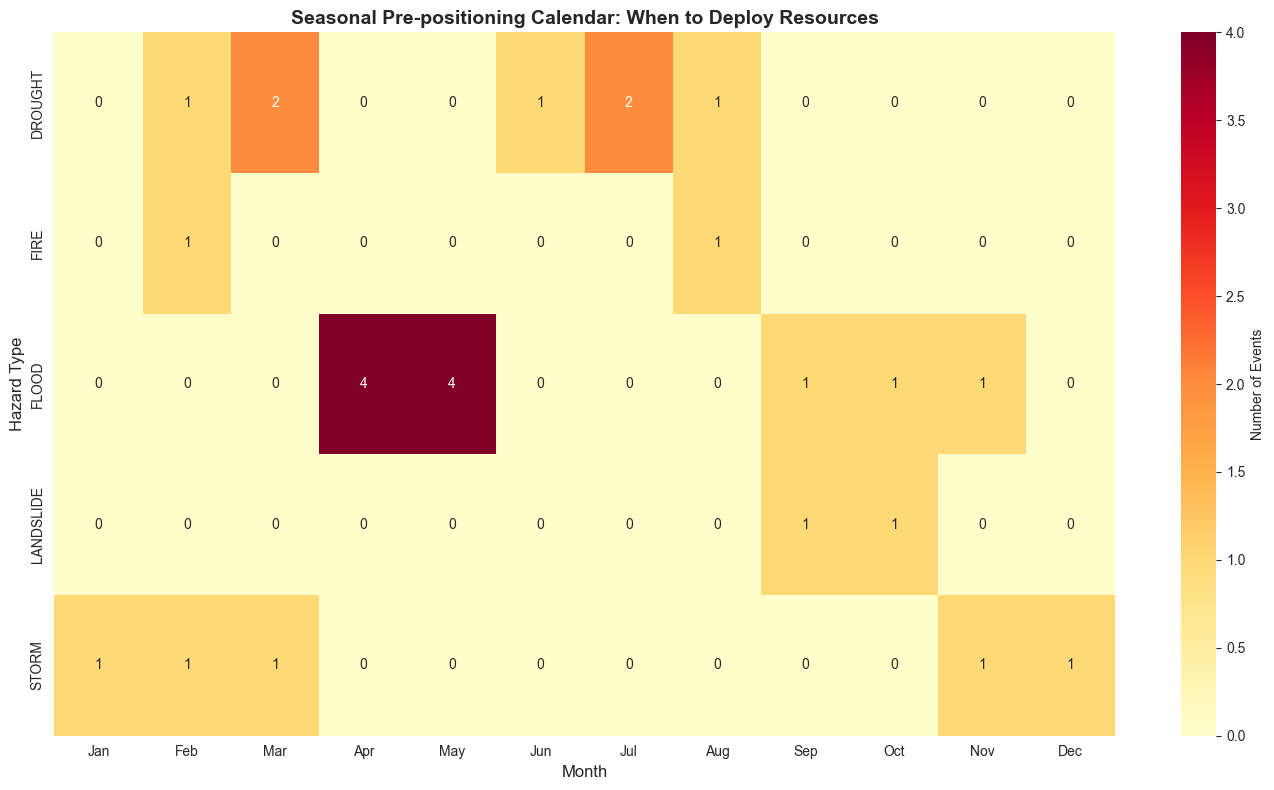


📅 PRE-POSITIONING SCHEDULE:

   DROUGHT:
   → Deploy resources BEFORE: Mar, Jul, Feb
   → Peak risk months: Mar, Jul, Feb

   FIRE:
   → Deploy resources BEFORE: Feb, Aug, Jan
   → Peak risk months: Feb, Aug, Jan

   FLOOD:
   → Deploy resources BEFORE: Apr, May, Sep
   → Peak risk months: Apr, May, Sep

   LANDSLIDE:
   → Deploy resources BEFORE: Sep, Oct, Jan
   → Peak risk months: Sep, Oct, Jan

   STORM:
   → Deploy resources BEFORE: Jan, Feb, Mar
   → Peak risk months: Jan, Feb, Mar


In [4]:
if df is not None and 'month' in df.columns and 'hazardtype' in df.columns:
    seasonal_pattern = df.groupby(['month', 'hazardtype']).size().reset_index(name='count')
    
    top_hazards = df['hazardtype'].value_counts().head(5).index
    seasonal_top = seasonal_pattern[seasonal_pattern['hazardtype'].isin(top_hazards)]
    
    pivot = seasonal_top.pivot(index='hazardtype', columns='month', values='count').fillna(0)
    
    month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                   'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
    pivot.columns = [month_names[int(m)-1] if m <= 12 else str(m) for m in pivot.columns]
    
    print("\n" + "="*80)
    print("SEASONAL PRE-POSITIONING CALENDAR")
    print("="*80)
    print("\nEvent frequency by month (top 5 hazards):\n")
    display(pivot)
    
    fig, ax = plt.subplots(figsize=(14, 8))
    sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd', 
                cbar_kws={'label': 'Number of Events'}, ax=ax)
    ax.set_title('Seasonal Pre-positioning Calendar: When to Deploy Resources', 
                 fontsize=14, fontweight='bold')
    ax.set_xlabel('Month', fontsize=12)
    ax.set_ylabel('Hazard Type', fontsize=12)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'UC2_seasonal_calendar.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("\n📅 PRE-POSITIONING SCHEDULE:")
    for hazard in pivot.index:
        peak_months = pivot.loc[hazard].nlargest(3)
        if peak_months.sum() > 0:
            print(f"\n   {hazard}:")
            print(f"   → Deploy resources BEFORE: {', '.join(peak_months.index)}")
            print(f"   → Peak risk months: {', '.join(peak_months.index)}")

## 4. Geographic Resource Allocation

### Where to Pre-position Emergency Supplies

In [5]:
if df is not None and 'level2' in df.columns:
    location_analysis = df.groupby('level2').agg({
        'serial': 'count',
        'hazardtype': 'nunique',
        'total_affected': 'sum',
        'total_deaths': 'sum'
    }).rename(columns={
        'serial': 'event_count',
        'hazardtype': 'hazard_diversity',
        'total_affected': 'total_affected',
        'total_deaths': 'total_deaths'
    })
    
    location_analysis['avg_affected_per_event'] = (
        location_analysis['total_affected'] / location_analysis['event_count']
    )
    
    for col in ['event_count', 'hazard_diversity', 'total_affected']:
        location_analysis[f'{col}_score'] = (
            (location_analysis[col] - location_analysis[col].min()) / 
            (location_analysis[col].max() - location_analysis[col].min())
        )
    
    location_analysis['preparedness_priority_score'] = (
        location_analysis['event_count_score'] * 0.4 +
        location_analysis['hazard_diversity_score'] * 0.3 +
        location_analysis['total_affected_score'] * 0.3
    )
    
    location_analysis = location_analysis.sort_values('preparedness_priority_score', ascending=False)
    
    print("\n" + "="*80)
    print("GEOGRAPHIC RESOURCE ALLOCATION PRIORITIES")
    print("="*80)
    print("\nTop 20 locations for emergency resource pre-positioning:\n")
    
    display(location_analysis.head(20))
    
    location_analysis.to_csv(REPORTS_DIR / 'UC2_resource_allocation_priorities.csv')
    print("\n✓ Resource allocation priorities saved")


GEOGRAPHIC RESOURCE ALLOCATION PRIORITIES

Top 20 locations for emergency resource pre-positioning:



,event_count,hazard_diversity,total_affected,total_deaths,avg_affected_per_event,event_count_score,hazard_diversity_score,total_affected_score,preparedness_priority_score
level2,,,,,,,,,
Nairobi,3,2,610209,164,203403.0,1.0,1.0,0.390008,0.817002
Eastern,2,2,1191567,306,595783.5,0.5,1.0,0.765792,0.729738
Western,2,2,1143834,358,571917.0,0.5,1.0,0.734938,0.720481
Rift Valley,2,2,620020,318,310010.0,0.5,1.0,0.396350,0.618905
Bay,1,1,1553900,2801,1553900.0,0.0,0.0,1.000000,0.300000
Banadir,1,1,1200000,312,1200000.0,0.0,0.0,0.771243,0.231373
Lower Shabelle,1,1,1136000,4120,1136000.0,0.0,0.0,0.729874,0.218962
Oromia,1,1,670000,178,670000.0,0.0,0.0,0.428656,0.128597
Northern,1,1,579678,179,579678.0,0.0,0.0,0.370273,0.111082



✓ Resource allocation priorities saved


## 5. Emergency Stockpile Sizing

### How Much to Pre-position

In [6]:
if df is not None and 'total_affected' in df.columns:
    affected_stats = df['total_affected'].describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99])
    
    print("\n" + "="*80)
    print("EMERGENCY STOCKPILE SIZING GUIDE")
    print("="*80)
    print("\nPeople affected per event (statistical distribution):\n")
    display(affected_stats)
    
    scenarios = {
        'Typical Event (50th percentile)': affected_stats['50%'],
        'Large Event (75th percentile)': affected_stats['75%'],
        'Major Event (90th percentile)': affected_stats['90%'],
        'Severe Event (95th percentile)': affected_stats['95%'],
        'Catastrophic Event (99th percentile)': affected_stats['99%']
    }
    
    supplies_per_person = {
        'Food (kg)': 15,
        'Water (liters)': 45,
        'Shelter (tarpaulins)': 0.2,
        'Hygiene kits': 0.2,
        'Medical supplies (units)': 0.1
    }
    
    print("\n📦 STOCKPILE REQUIREMENTS (3-day emergency response):\n")
    
    stockpile_df = []
    for scenario, people in scenarios.items():
        if not np.isnan(people):
            print(f"\n{scenario}: {people:,.0f} people")
            row = {'Scenario': scenario, 'People': people}
            for item, per_person in supplies_per_person.items():
                quantity = people * per_person
                row[item] = quantity
                print(f"   - {item}: {quantity:,.0f}")
            stockpile_df.append(row)
    
    stockpile_df = pd.DataFrame(stockpile_df)
    stockpile_df.to_csv(REPORTS_DIR / 'UC2_stockpile_requirements.csv', index=False)
    
    print("\n💡 RECOMMENDATION:")
    print(f"   Pre-position supplies for {scenarios['Large Event (75th percentile)']:,.0f} people")
    print("   (75th percentile covers most events while remaining cost-effective)")


EMERGENCY STOCKPILE SIZING GUIDE

People affected per event (statistical distribution):



count    3.000000e+01
mean     3.894036e+05
std      4.188997e+05
min      6.845000e+03
50%      2.012895e+05
75%      5.745038e+05
90%      1.126280e+06
95%      1.171200e+06
99%      1.451269e+06
max      1.553900e+06
Name: total_affected, dtype: float64


📦 STOCKPILE REQUIREMENTS (3-day emergency response):


Typical Event (50th percentile): 201,290 people
   - Food (kg): 3,019,342
   - Water (liters): 9,058,028
   - Shelter (tarpaulins): 40,258
   - Hygiene kits: 40,258
   - Medical supplies (units): 20,129

Large Event (75th percentile): 574,504 people
   - Food (kg): 8,617,556
   - Water (liters): 25,852,669
   - Shelter (tarpaulins): 114,901
   - Hygiene kits: 114,901
   - Medical supplies (units): 57,450

Major Event (90th percentile): 1,126,280 people
   - Food (kg): 16,894,200
   - Water (liters): 50,682,600
   - Shelter (tarpaulins): 225,256
   - Hygiene kits: 225,256
   - Medical supplies (units): 112,628

Severe Event (95th percentile): 1,171,200 people
   - Food (kg): 17,568,000
   - Water (liters): 52,704,000
   - Shelter (tarpaulins): 234,240
   - Hygiene kits: 234,240
   - Medical supplies (units): 117,120

Catastrophic Event (99th percentile): 1,451,269 people
   - Food (kg): 21,769,035
   - Water (liters): 65,307,105
  

## 6. Capacity Gap Analysis

### Infrastructure Needs Assessment

In [7]:
if df is not None and 'level2' in df.columns:
    capacity_gaps = df.groupby('level2').agg({
        'serial': 'count',
        'healthcenters': 'sum',
        'educationcenters': 'sum',
        'total_affected': 'mean'
    }).rename(columns={
        'serial': 'event_count',
        'healthcenters': 'health_facilities_damaged',
        'educationcenters': 'education_facilities_damaged',
        'total_affected': 'avg_people_affected'
    })
    
    capacity_gaps['health_capacity_gap'] = (
        capacity_gaps['health_facilities_damaged'] / capacity_gaps['event_count']
    )
    
    capacity_gaps['education_capacity_gap'] = (
        capacity_gaps['education_facilities_damaged'] / capacity_gaps['event_count']
    )
    
    capacity_gaps = capacity_gaps.sort_values('health_capacity_gap', ascending=False)
    
    print("\n" + "="*80)
    print("CAPACITY GAP ANALYSIS - INFRASTRUCTURE NEEDS")
    print("="*80)
    print("\nLocations with highest infrastructure damage (top 15):\n")
    
    display(capacity_gaps.head(15))
    
    print("\n🏥 CAPACITY BUILDING PRIORITIES:")
    print("\n   HIGH PRIORITY (health facilities):")
    high_health = capacity_gaps.nlargest(5, 'health_capacity_gap')
    for location in high_health.index:
        avg_damage = high_health.loc[location, 'health_capacity_gap']
        print(f"   → {location}: {avg_damage:.1f} facilities damaged per event")
    
    print("\n   Recommendations:")
    print("   - Strengthen existing health facilities")
    print("   - Pre-position mobile medical units")
    print("   - Train community health workers")
    
    capacity_gaps.to_csv(REPORTS_DIR / 'UC2_capacity_gaps.csv')


CAPACITY GAP ANALYSIS - INFRASTRUCTURE NEEDS

Locations with highest infrastructure damage (top 15):



,event_count,health_facilities_damaged,education_facilities_damaged,avg_people_affected,health_capacity_gap,education_capacity_gap
level2,,,,,,
Bay,1,67,234,1553900.0,67.000000,234.000000
Somali,1,23,89,338450.0,23.000000,89.000000
Lower Shabelle,1,23,78,1136000.0,23.000000,78.000000
Northern,1,15,56,579678.0,15.000000,56.000000
Nyanza,1,12,45,113200.0,12.000000,45.000000
Western,2,19,72,571917.0,9.500000,36.000000
Morogoro,1,9,34,301890.0,9.000000,34.000000
Rift Valley,2,14,53,310010.0,7.000000,26.500000
Central,1,6,23,201234.0,6.000000,23.000000



🏥 CAPACITY BUILDING PRIORITIES:

   HIGH PRIORITY (health facilities):
   → Bay: 67.0 facilities damaged per event
   → Somali: 23.0 facilities damaged per event
   → Lower Shabelle: 23.0 facilities damaged per event
   → Northern: 15.0 facilities damaged per event
   → Nyanza: 12.0 facilities damaged per event

   Recommendations:
   - Strengthen existing health facilities
   - Pre-position mobile medical units
   - Train community health workers


## 7. Response Time Optimization

### Strategic Warehouse Locations

In [8]:
if df is not None and 'level2' in df.columns:
    top_20_locations = location_analysis.head(20)
    
    print("\n" + "="*80)
    print("STRATEGIC WAREHOUSE LOCATION RECOMMENDATIONS")
    print("="*80)
    print("\nBased on event frequency, hazard diversity, and population affected\n")
    
    print("TIER 1 - REGIONAL HUBS (5 locations):")
    print("   Full emergency response capacity, 24/7 operations\n")
    for i, location in enumerate(top_20_locations.head(5).index, 1):
        events = top_20_locations.loc[location, 'event_count']
        hazards = top_20_locations.loc[location, 'hazard_diversity']
        print(f"   {i}. {location}")
        print(f"      Events: {events}, Hazard types: {hazards}")
    
    print("\nTIER 2 - DISTRICT CENTERS (10 locations):")
    print("   Pre-positioned supplies, rapid response teams\n")
    for i, location in enumerate(top_20_locations.iloc[5:15].index, 6):
        events = top_20_locations.loc[location, 'event_count']
        print(f"   {i}. {location} ({events} events)")
    
    print("\nTIER 3 - FORWARD BASES (5 locations):")
    print("   Basic supplies, community-based response\n")
    for i, location in enumerate(top_20_locations.iloc[15:20].index, 16):
        events = top_20_locations.loc[location, 'event_count']
        print(f"   {i}. {location} ({events} events)")


STRATEGIC WAREHOUSE LOCATION RECOMMENDATIONS

Based on event frequency, hazard diversity, and population affected

TIER 1 - REGIONAL HUBS (5 locations):
   Full emergency response capacity, 24/7 operations

   1. Nairobi
      Events: 3, Hazard types: 2
   2. Eastern
      Events: 2, Hazard types: 2
   3. Western
      Events: 2, Hazard types: 2
   4. Rift Valley
      Events: 2, Hazard types: 2
   5. Bay
      Events: 1, Hazard types: 1

TIER 2 - DISTRICT CENTERS (10 locations):
   Pre-positioned supplies, rapid response teams

   6. Banadir (1 events)
   7. Lower Shabelle (1 events)
   8. Oromia (1 events)
   9. Northern (1 events)
   10. North Eastern (1 events)
   11. Kagera (1 events)
   12. Somali (1 events)
   13. Morogoro (1 events)
   14. Sofala (1 events)
   15. Central (1 events)

TIER 3 - FORWARD BASES (5 locations):
   Basic supplies, community-based response

   16. Nampula (1 events)
   17. Addis Ababa (1 events)
   18. Nyanza (1 events)
   19. Dar es Salaam (1 events)


## 8. Training and Drill Schedule

In [9]:
if df is not None and 'hazardtype' in df.columns:
    print("\n" + "="*80)
    print("TRAINING AND DRILL SCHEDULE RECOMMENDATIONS")
    print("="*80)
    
    top_hazards = df['hazardtype'].value_counts().head(5)
    
    print("\nBased on hazard frequency, prioritize training for:\n")
    
    for i, (hazard, count) in enumerate(top_hazards.items(), 1):
        annual_avg = count / years_covered
        
        if annual_avg >= 10:
            frequency = "QUARTERLY"
        elif annual_avg >= 5:
            frequency = "SEMI-ANNUAL"
        else:
            frequency = "ANNUAL"
        
        print(f"{i}. {hazard}")
        print(f"   Frequency: {annual_avg:.1f} events/year")
        print(f"   Drill schedule: {frequency}")
        print(f"   Training focus: Response protocols, equipment use, coordination\n")
    
    print("\n📋 TRAINING PRIORITIES:")
    print("   1. First responder training (all hazards)")
    print("   2. Hazard-specific response protocols")
    print("   3. Coordination and communication drills")
    print("   4. Community-based disaster response")
    print("   5. Search and rescue operations")


TRAINING AND DRILL SCHEDULE RECOMMENDATIONS

Based on hazard frequency, prioritize training for:

1. FLOOD
   Frequency: 0.8 events/year
   Drill schedule: ANNUAL
   Training focus: Response protocols, equipment use, coordination

2. DROUGHT
   Frequency: 0.5 events/year
   Drill schedule: ANNUAL
   Training focus: Response protocols, equipment use, coordination

3. STORM
   Frequency: 0.4 events/year
   Drill schedule: ANNUAL
   Training focus: Response protocols, equipment use, coordination

4. LANDSLIDE
   Frequency: 0.1 events/year
   Drill schedule: ANNUAL
   Training focus: Response protocols, equipment use, coordination

5. FIRE
   Frequency: 0.1 events/year
   Drill schedule: ANNUAL
   Training focus: Response protocols, equipment use, coordination


📋 TRAINING PRIORITIES:
   1. First responder training (all hazards)
   2. Hazard-specific response protocols
   3. Coordination and communication drills
   4. Community-based disaster response
   5. Search and rescue operations


## 9. Executive Summary for Disaster Management Authorities

In [10]:
if df is not None:
    print("\n" + "="*80)
    print("EXECUTIVE BRIEFING: DISASTER PREPAREDNESS STRATEGY")
    print("For: National Disaster Management Authority")
    print("="*80)
    
    print("\n1. PREPAREDNESS REQUIREMENTS:")
    permanent_hazards = freq_df[freq_df['Preparedness Level'] == 'PERMANENT']
    if len(permanent_hazards) > 0:
        print(f"   → Maintain permanent capacity for: {', '.join(permanent_hazards['Hazard'].values)}")
    
    print(f"\n2. RESOURCE PRE-POSITIONING:")
    print(f"   → Establish {5} regional hubs (Tier 1)")
    print(f"   → Deploy to {10} district centers (Tier 2)")
    print(f"   → Support {5} forward bases (Tier 3)")
    
    print(f"\n3. STOCKPILE TARGETS:")
    target_people = scenarios.get('Large Event (75th percentile)', 0)
    print(f"   → Size for {target_people:,.0f} affected people")
    print("   → 3-day emergency supplies at each hub")
    
    print(f"\n4. CAPACITY BUILDING:")
    print("   → Strengthen health facilities in high-risk areas")
    print("   → Conduct quarterly drills for high-frequency hazards")
    print("   → Train community-based response teams")
    
    print(f"\n5. DATA ADVANTAGE:")
    print("   ✓ Evidence-based resource allocation")
    print("   ✓ Optimized pre-positioning timing")
    print("   ✓ Targeted capacity building")
    print("   ✓ Cost-effective preparedness strategy")
    
    print("\n" + "="*80)


EXECUTIVE BRIEFING: DISASTER PREPAREDNESS STRATEGY
For: National Disaster Management Authority

1. PREPAREDNESS REQUIREMENTS:

2. RESOURCE PRE-POSITIONING:
   → Establish 5 regional hubs (Tier 1)
   → Deploy to 10 district centers (Tier 2)
   → Support 5 forward bases (Tier 3)

3. STOCKPILE TARGETS:
   → Size for 574,504 affected people
   → 3-day emergency supplies at each hub

4. CAPACITY BUILDING:
   → Strengthen health facilities in high-risk areas
   → Conduct quarterly drills for high-frequency hazards
   → Train community-based response teams

5. DATA ADVANTAGE:
   ✓ Evidence-based resource allocation
   ✓ Optimized pre-positioning timing
   ✓ Targeted capacity building
   ✓ Cost-effective preparedness strategy

